In [15]:
%load_ext autoreload
%autoreload 2

import importlib
import park_pifm
importlib.reload(park_pifm)

from park_pifm import (read_park_pifm_tiff, read_info_txt,
                       plot_topo_spectra, save_spectra, detect_peaks,
                       plot_avg_spectrum, plot_overlay_spectra, 
                       plot_overlay_normalized_stacked, plot_overlay_normalized)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import re, os

# ── 파일 경로 ──────────────────────────────────────────────────
dir_path = '../data/raw/'
fname = 'ex_film_re_points_260514__218.tiff'
filepath = dir_path + fname
filepath_info = 'test.txt'  # 있으면 사용

m = re.search(r'__(\d+)\.tiff$', fname)
file_num = m.group(1) if m else fname.rsplit('.', 1)[0]

out_dir = f'../output/{file_num}'
os.makedirs(out_dir, exist_ok=True)

print(filepath)
print(f"File number : {file_num}")
print(f"Output dir  : {out_dir}")

../data/raw/ex_film_re_points_260514__218.tiff
File number : 218
Output dir  : ../output/218


In [363]:
# ── 파일 읽기 ──────────────────────────────────────────────────
data = read_park_pifm_tiff(filepath)
print(f"Scan size : {data['scan_x_nm']:.0f} x {data['scan_y_nm']:.0f} nm")
print(f"Z range   : {data['z_nm'].min():.3f} ~ {data['z_nm'].max():.3f} nm")
print(f"Points    : {data['n_pts']}")
print(f"WN range  : {data['points'][0]['wavenumber'].min():.1f}"
      f" ~ {data['points'][0]['wavenumber'].max():.1f} cm⁻¹")

Scan size : 1000 x 1000 nm
Z range   : -1.498 ~ 1.671 nm
Points    : 9
WN range  : 765.5 ~ 1886.7 cm⁻¹


In [364]:
# ── 포인트 좌표: info.txt 우선, 없으면 raw 파일에서 자동 추출 ──
import os
if os.path.exists(filepath_info):
    coords_nm = read_info_txt(filepath_info)
    print('Coords from info.txt')
else:
    coords_nm = data['coords_nm']
    print('Coords from raw TIFF')

Coords from raw TIFF


In [365]:
print('Coords (nm):')
for i, (x, y) in enumerate(coords_nm):
    print(f'  Pt{i+1}: X={x:.1f}, Y={y:.1f}')

Coords (nm):
  Pt1: X=225.7, Y=850.7
  Pt2: X=458.7, Y=836.2
  Pt3: X=730.6, Y=824.0
  Pt4: X=628.6, Y=481.8
  Pt5: X=466.0, Y=418.7
  Pt6: X=259.7, Y=423.5
  Pt7: X=155.3, Y=246.4
  Pt8: X=466.0, Y=207.5
  Pt9: X=876.2, Y=195.4


In [238]:
# ── 데이터 저장 (Excel + Origin txt) ──────────────────────────
save_spectra(data, channel='amplitude_uV', filepath=f'{out_dir}/result_{file_num}')

Saved: ../output/677/result_677_amplitude_uV.xlsx
Saved: ../output/677/result_677_amplitude_uV.txt


In [247]:
peaks = detect_peaks(data, [7],
                     xlim=(700, 2400),
                     height=1.0,       # 피크 최소 높이 (0~1, 높일수록 작은 피크 제외)
                     prominence=0.30,
                     width = 30,   # 주변 대비 돌출 정도 (높일수록 노이즈 제외)
                     distance=20)       # 인접 피크 간 최소 간격 (포인트 수)
# 플롯 확인 후 필요하면 직접 수정:
# peaks = [1110, 1223, 1300, 1727]


검출된 피크: [1263]
→ 이상이 없으면 plot_topo_spectra(..., peaks=peaks) 로 전달하세요.
→ 수정이 필요하면:  peaks = [1100, 1229, ...]  직접 입력 후 재실행하세요.


In [9]:
%matplotlib tk

import matplotlib.pyplot as plt
dat_point_num = 2
wn  = data['points'][dat_point_num]['wavenumber']       # 3번 포인트 (0-based이므로 index=2)
amp = data['points'][dat_point_num]['amplitude_uV']


plt.plot(wn, amp)

NameError: name 'data' is not defined

In [366]:
#peaks = [1013, 1104, 1261, 1437, 1574]
plot_topo_spectra(data,
                  coords_nm=coords_nm,
                  channel='amplitude_uV',
                  xlim=(700, 2400),
                  stack_gap=1.1,
                  title=f'#{file_num}',
                  save_path=f'{out_dir}/result_{file_num}_topo_amplitude.png')

Saved: ../output/218/result_218_topo_amplitude.png


## 평균 스펙트럼 — 선택 포인트

In [3]:
# ── 선택 포인트 평균 스펙트럼 플롯 + 저장 ─────────────────────
# point_indices: 사용할 포인트 번호 (1-based). None → 전체 평균
# normalize: False → 원본 단위(μV), True → 0~1 정규화
plot_avg_spectrum(data,
                 point_indices=[1, 2, 3, 4, 5],
                 channel='amplitude_uV',
                 xlim=(700, 2400),
                 normalize=False,
                 title=f'#{file_num} — avg',
                 save_path=f'{out_dir}/result_{file_num}_avg.png',
                 filepath=f'{out_dir}/result_{file_num}')

NameError: name 'data' is not defined

## 스캔 비교 — Overlay

In [4]:
# ── 여러 스캔 데이터 로드 ──────────────────────────────────────
data_A = read_park_pifm_tiff('../data/raw/NF_pos2_sb_l1.5_points_260619__141.tiff')
data_B = read_park_pifm_tiff('../data/raw/TF_pos2_sb_l1.5_points_260619__261.tiff')
data_C = read_park_pifm_tiff('../data/raw/ps_p1_sb_l1_on_p_points_260514__085.tiff')
data_D = read_park_pifm_tiff('../data/raw/ps_p1_sb_l1_film_pos2_points_re_260514__140.tiff')
data_E = read_park_pifm_tiff('../data/raw/ex_p_points_260514__184.tiff')
data_F = read_park_pifm_tiff('../data/raw/ex_film_re_points_260514__218.tiff')

Saved: ../output/overlay/overlay.png


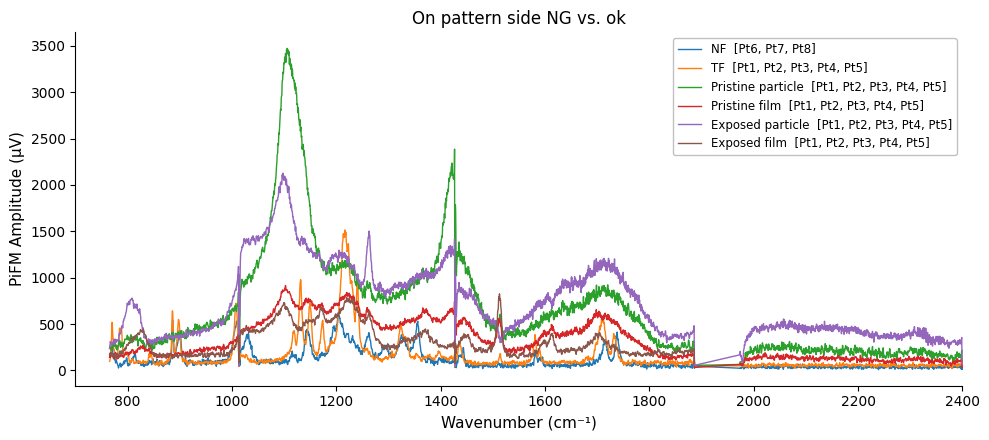

Saved: ../output/overlay/overlay_overlay_amplitude_uV.xlsx
Saved: ../output/overlay/overlay_overlay_amplitude_uV.txt


[('NF',
  array([ 765.52,  766.02,  766.52, ..., 2399.05, 2399.55, 2399.55],
        shape=(3098,), dtype=float32),
  array([144.40778 , 164.81926 , 166.88058 , ...,  10.306636,  38.10351 ,
          38.10351 ], shape=(3098,), dtype=float32)),
 ('TF',
  array([ 765.52,  766.02,  766.52, ..., 2399.05, 2399.55, 2399.55],
        shape=(3098,), dtype=float32),
  array([ 97.66408 , 104.527916, 124.709694, ...,  39.79728 ,  52.593647,
          52.593647], shape=(3098,), dtype=float32)),
 ('Pristine particle',
  array([ 765.52,  766.02,  766.52, ..., 2399.05, 2399.55, 2399.55],
        shape=(3098,), dtype=float32),
  array([240.46936, 250.01352, 244.20769, ...,  95.11225, 101.68925,
         101.68925], shape=(3098,), dtype=float32)),
 ('Pristine film',
  array([ 765.52,  766.02,  766.52, ..., 2399.05, 2399.55, 2399.55],
        shape=(3098,), dtype=float32),
  array([142.78851 , 159.2599  , 152.66054 , ...,  31.342731,  36.332756,
          36.332756], shape=(3098,), dtype=float32)),
 ('E

In [ ]:
# ── 스캔별 평균 스펙트럼 겹쳐 그리기 ─────────────────────────
# normalize: False → 원본 단위(μV) 그대로 비교, True → 0~1 정규화 비교
overlay_out_dir = '../output/overlay'
os.makedirs(overlay_out_dir, exist_ok=True)

scan_list_norm = [
    {'data': data_A, 'label': 'NF', 'point_indices': [6, 7, 8]},
    {'data': data_B, 'label': 'TF', 'point_indices': [1, 2, 3, 4, 5]},
    {'data': data_C, 'label': 'Pristine particle', 'point_indices': [1, 2, 3, 4, 5]},
    {'data': data_D, 'label': 'Pristine film', 'point_indices': [1, 2, 3, 4, 5]},
    {'data': data_E, 'label': 'Exposed particle', 'point_indices': [1, 2, 3, 4, 5]},
    {'data': data_F, 'label': 'Exposed film', 'point_indices': [1, 2, 3, 4, 5]},
]

plot_overlay_spectra(scan_list_norm,
                     channel='amplitude_uV',
                     xlim=(700, 2400),
                     normalize=False,
                     title='NF, TF, pri_p, pri_f, exp_p, exp_f',
                     save_path=f'{overlay_out_dir}/overlay.png',
                     filepath=f'{overlay_out_dir}/overlay')

## Normalized Overlay (max 정규화)

In [21]:
import os

# ── Normalized overlay: 각 스펙트럼을 최대값으로 정규화 후 비교 ────────────
# peaks: 표시할 피크 위치 리스트. None 이면 마커 없음
# save_path / filepath 로 이미지·데이터 저장 (만족하면 주석 해제)

overlay_norm_dir = '../output/overlay'
os.makedirs(overlay_norm_dir, exist_ok=True)

scan_list_norm = [
    {'data': data_A, 'label': 'NF', 'point_indices': [6, 7, 8]},
    {'data': data_B, 'label': 'TF', 'point_indices': [1, 2, 3, 4, 5]},
    {'data': data_D, 'label': 'Pristine film', 'point_indices': [1, 2, 3, 4, 5]},
    {'data': data_F, 'label': 'Exposed film', 'point_indices': [1, 2, 3, 4, 5]},
    {'data': data_C, 'label': 'Pristine particle', 'point_indices': [1, 2, 3, 4, 5]},
    {'data': data_E, 'label': 'Exposed particle', 'point_indices': [1, 2, 3, 4, 5]},
]

peaks_norm = [812, 1025, 1100, 1263] # 직접 지정 (또는 detect_peaks 결과 사용)

plot_overlay_normalized(
    scan_list_norm,
    channel='amplitude_uV',
    xlim=(750, 1800),
    peaks = peaks_norm,
    title='Particle vs. film',
    # save_path=f'{overlay_norm_dir}/overlay_norm.png',    # 만족하면 주석 해제
    # filepath=f'{overlay_norm_dir}/overlay_norm',          # 만족하면 주석 해제
)

[('NF',
  array([ 765.52,  766.02,  766.52, ..., 1798.66, 1799.16, 1799.66],
        shape=(2070,), dtype=float32),
  array([0.23053898, 0.26312476, 0.26641557, ..., 0.11046463, 0.12389048,
         0.08243341], shape=(2070,), dtype=float32)),
 ('TF',
  array([ 765.52,  766.02,  766.52, ..., 1798.66, 1799.16, 1799.66],
        shape=(2070,), dtype=float32),
  array([0.06447016, 0.06900113, 0.08232356, ..., 0.0465307 , 0.0366597 ,
         0.03809706], shape=(2070,), dtype=float32)),
 ('Pristine film',
  array([ 765.52,  766.02,  766.52, ..., 1798.66, 1799.16, 1799.66],
        shape=(2070,), dtype=float32),
  array([0.15596789, 0.1739596 , 0.1667511 , ..., 0.22838426, 0.24741155,
         0.2580055 ], shape=(2070,), dtype=float32)),
 ('Exposed film',
  array([ 765.52,  766.02,  766.52, ..., 1798.66, 1799.16, 1799.66],
        shape=(2070,), dtype=float32),
  array([0.21146604, 0.22590801, 0.21915853, ..., 0.21375574, 0.2148363 ,
         0.21755913], shape=(2070,), dtype=float32)),
 ('

In [22]:
plot_overlay_normalized_stacked(
    scan_list_norm,
    channel='amplitude_uV',
    xlim=(750, 1800),
    stack_gap=0.5,          # 스펙트럼 간 수직 간격 (조절 가능)
    peaks=peaks_norm,
    title='Stacked Normalized Overlay',
    # save_path=f'{overlay_norm_dir}/overlay_norm_stacked.png',
    # filepath=f'{overlay_norm_dir}/overlay_norm_stacked',
)

[('NF',
  array([ 765.52,  766.02,  766.52, ..., 1798.66, 1799.16, 1799.66],
        shape=(2070,), dtype=float32),
  array([0.23053898, 0.26312476, 0.26641557, ..., 0.11046463, 0.12389048,
         0.08243341], shape=(2070,), dtype=float32)),
 ('TF',
  array([ 765.52,  766.02,  766.52, ..., 1798.66, 1799.16, 1799.66],
        shape=(2070,), dtype=float32),
  array([0.06447016, 0.06900113, 0.08232356, ..., 0.0465307 , 0.0366597 ,
         0.03809706], shape=(2070,), dtype=float32)),
 ('Pristine film',
  array([ 765.52,  766.02,  766.52, ..., 1798.66, 1799.16, 1799.66],
        shape=(2070,), dtype=float32),
  array([0.15596789, 0.1739596 , 0.1667511 , ..., 0.22838426, 0.24741155,
         0.2580055 ], shape=(2070,), dtype=float32)),
 ('Exposed film',
  array([ 765.52,  766.02,  766.52, ..., 1798.66, 1799.16, 1799.66],
        shape=(2070,), dtype=float32),
  array([0.21146604, 0.22590801, 0.21915853, ..., 0.21375574, 0.2148363 ,
         0.21755913], shape=(2070,), dtype=float32)),
 ('